# Shannon Information Entropy — Worked Examples
## Applying $H(\mathcal{X})$ to Digital and Genomic Data

> 📺 **[Watch the original lecture on YouTube](https://youtu.be/DCQpbssp_Sw)**

This notebook follows the second lecture in the Shannon information theory series. The goal here is to **crystallize** the abstract formula derived in [Part 1](../Video_01/Shannon_Entropy.ipynb) by walking through two concrete examples:

1. A **digital data set** — a string of binary bits (0s and 1s).
2. A **genomic sequence** — a string of nucleotides (A, C, T, G).

In each case we will compute $H(\mathcal{X})$ by hand, verify it numerically, and discuss how the result compares to the theoretical maximum $H_{\max} = \log_2(U)$.

---

> 🧭 **Navigation** · [← Part 1: Introduction to Shannon's Information Theory](../Video_01/Shannon_Entropy.ipynb) · **Part 2 (current)** · *Part 3: coming soon*

---

## Refresher: The Shannon Information Entropy Formula

From [Part 1](../Video_01/Shannon_Entropy.ipynb), the Shannon information entropy of a discrete source with $U$ distinct symbols and probability distribution $\{p_1, p_2, \ldots, p_U\}$ is:

$$H(\mathcal{X}) = -\sum_{j=1}^{U} p_j \log_2(p_j) \quad \text{[bits]}$$

We use **base 2** throughout this lecture so that $H(\mathcal{X})$ has units of **bits** per character.

### Notation reminder

| Symbol | Meaning |
|---|---|
| $\mathcal{X}$ | The set of **distinct** characters |
| $U$ | Number of distinct characters, $\;U = \lvert \mathcal{X} \rvert$ |
| $N$ | **Total** number of characters in the message (may include repeats) |
| $p_j$ | Probability of character $x_j \in \mathcal{X}$ |
| $H(\mathcal{X})$ | Shannon entropy — information **per character** |
| $I_{\text{total}}$ | Total information in the message: $I_{\text{total}} = N \cdot H(\mathcal{X})$ |
| $H_{\max}$ | Maximum possible entropy: $H_{\max} = \log_2(U)$, when all $p_j = 1/U$ |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def shannon_entropy(probabilities, base=2):
    """Shannon entropy H = -sum(p * log_b(p)).  Skips zero-probability terms."""
    p = np.asarray(probabilities, dtype=float)
    p = p[p > 0]
    assert np.isclose(p.sum(), 1.0), f"Probabilities must sum to 1 (got {p.sum()})"
    return -np.sum(p * np.log(p) / np.log(base))

def entropy_of_message(message, base=2):
    """Compute H(X) directly from a sequence of symbols (string or list)."""
    N = len(message)
    counts = Counter(message)
    probs = [c / N for c in counts.values()]
    return shannon_entropy(probs, base=base), counts

## Example 1 — A Digital Data Set (Binary)

### Setup

Consider a **digital data set**: a string of bits. The alphabet is:

$$\mathcal{X} = \{0, 1\} \implies U = 2$$

For simplicity, take $N = 10$ characters:

$$\text{message} = 0,\, 1,\, 1,\, 1,\, 1,\, 0,\, 1,\, 1,\, 0,\, 1$$

### Theoretical maximum

Before computing anything, recall the upper bound:

$$H_{\max} = \log_2(U) = \log_2(2) = 1 \text{ bit / character}$$

This maximum is reached **only** when the distribution is uniform (5 zeros and 5 ones). In that ideal case the total information would be:

$$I_{\text{total, max}} = N \cdot H_{\max} = 10 \cdot 1 = 10 \text{ bits}$$

### Actual probability distribution

Counting the message: **3 zeros** and **7 ones**, giving:

$$p_0 = \frac{3}{10}, \qquad p_1 = \frac{7}{10}$$

### Applying the entropy formula

$$H(\mathcal{X}) = -\left[ p_0 \log_2(p_0) + p_1 \log_2(p_1) \right]$$

$$H(\mathcal{X}) = -\left[ \tfrac{3}{10}\log_2\!\left(\tfrac{3}{10}\right) + \tfrac{7}{10}\log_2\!\left(\tfrac{7}{10}\right) \right] \approx 0.881 \text{ bits / character}$$

$$I_{\text{total}} = N \cdot H(\mathcal{X}) = 10 \cdot 0.881 \approx 8.81 \text{ bits}$$

The imbalance (more 1s than 0s) makes the message **less surprising on average**, so we encode less information per character than the theoretical maximum.

### Presenter's Notes — Binary Example Worked Out
![Binary digital example](Screenshots/Part_2_00_07_45.jpg)

*Screenshot at timestamp 00:07:45*

---

In [2]:
# Example 1 — Binary digital data set
message_bits = [0, 1, 1, 1, 1, 0, 1, 1, 0, 1]
N = len(message_bits)

H_bits, counts = entropy_of_message(message_bits)
H_max_bits = np.log2(2)
I_total_bits = N * H_bits
I_total_max_bits = N * H_max_bits

print(f"Message:          {message_bits}")
print(f"N = {N},  U = {len(counts)}")
print(f"Counts:           {dict(counts)}")
print(f"Probabilities:    p(0) = {counts[0]/N:.2f},  p(1) = {counts[1]/N:.2f}")
print()
print(f"H_max  = log2(U) = {H_max_bits:.4f} bits / character  (uniform distribution)")
print(f"H(X)             = {H_bits:.4f} bits / character  (actual)")
print(f"Efficiency       = {H_bits / H_max_bits * 100:.1f}% of maximum")
print()
print(f"I_total (max)    = N * H_max = {I_total_max_bits:.2f} bits")
print(f"I_total (actual) = N * H(X)  = {I_total_bits:.2f} bits")

Message:          [0, 1, 1, 1, 1, 0, 1, 1, 0, 1]
N = 10,  U = 2
Counts:           {0: 3, 1: 7}
Probabilities:    p(0) = 0.30,  p(1) = 0.70

H_max  = log2(U) = 1.0000 bits / character  (uniform distribution)
H(X)             = 0.8813 bits / character  (actual)
Efficiency       = 88.1% of maximum

I_total (max)    = N * H_max = 10.00 bits
I_total (actual) = N * H(X)  = 8.81 bits


---
## Example 2 — A Genomic Sequence (DNA / RNA)

### Biological background

Any **genomic sequence** — whether DNA (double helix) or RNA (single helix) — can be simplified to a string of four characters representing the **nucleotides**:

| Symbol | Nucleotide (DNA) |
|---|---|
| **A** | Adenine |
| **C** | Cytosine |
| **T** | Thymine |
| **G** | Guanine |

In RNA, thymine (**T**) is replaced by uracil (**U**), but the mathematics is identical. So:

$$\mathcal{X} = \{A, C, T, G\} \implies U = 4$$

### Theoretical maximum

$$H_{\max} = \log_2(U) = \log_2(4) = 2 \text{ bits / character}$$

Each nucleotide can carry **at most 2 bits** of information.

### Binary encoding of nucleotides

Because $H_{\max} = 2$ bits, we can losslessly digitize each nucleotide using **2 bits**. One natural assignment is:

| Nucleotide | Binary code |
|---|---|
| A | `00` |
| C | `01` |
| T | `10` |
| G | `11` |

These are simply the four 2-bit permutations. Under this encoding, $\mathcal{X}' = \{00, 01, 10, 11\}$ — still four symbols, but represented as digital bits. We could then apply the binary entropy analysis from Example 1 to the bit string. However, **this is not necessary** — we can compute entropy directly on the nucleotide alphabet, which is what we'll do below.

### Presenter's Notes — Binary Encoding of Nucleotides
![A=00, C=01, T=10, G=11](Screenshots/Part_2_00_13_02.jpg)

*Screenshot at timestamp 00:13:02*

---

### A hypothetical 10-nucleotide segment

Take an arbitrary $N = 10$ "mini-genome" segment:

$$\text{message} = C,\, A,\, A,\, T,\, T,\, T,\, T,\, G,\, A,\, C$$

Counting each nucleotide:

| Nucleotide | Count | Probability |
|---|---|---|
| A | 3 | $p_A = 3/10$ |
| C | 2 | $p_C = 2/10$ |
| T | 4 | $p_T = 4/10$ |
| G | 1 | $p_G = 1/10$ |

*Mental model for probability: imagine the 10 letters mixed face-down on a table. Close your eyes, draw one at random — the probability of drawing each letter is its frequency divided by $N$.*

### Applying the entropy formula

$$H(\mathcal{X}) = -\sum_{j=1}^{4} p_j \log_2(p_j)$$

$$H(\mathcal{X}) = -\left[ \tfrac{3}{10}\log_2\!\tfrac{3}{10} + \tfrac{2}{10}\log_2\!\tfrac{2}{10} + \tfrac{1}{10}\log_2\!\tfrac{1}{10} + \tfrac{4}{10}\log_2\!\tfrac{4}{10} \right]$$

$$H(\mathcal{X}) \approx 1.846 \text{ bits / character}$$

$$I_{\text{total}} = N \cdot H(\mathcal{X}) = 10 \cdot 1.846 \approx 18.46 \text{ bits}$$

The theoretical maximum would be $I_{\text{total, max}} = N \cdot H_{\max} = 10 \cdot 2 = 20$ bits.

In [3]:
# Example 2 — Genomic sequence
message_dna = ['C', 'A', 'A', 'T', 'T', 'T', 'T', 'G', 'A', 'C']
N = len(message_dna)

H_dna, counts = entropy_of_message(message_dna)
H_max_dna = np.log2(4)
I_total_dna = N * H_dna
I_total_max_dna = N * H_max_dna

print(f"Message:          {''.join(message_dna)}")
print(f"N = {N},  U = {len(counts)}")
print(f"Counts:           {dict(counts)}")
print("Probabilities:")
for symbol in ['A', 'C', 'T', 'G']:
    print(f"  p({symbol}) = {counts[symbol]}/{N} = {counts[symbol]/N:.2f}")
print()
print(f"H_max  = log2(U) = {H_max_dna:.4f} bits / character  (uniform distribution)")
print(f"H(X)             = {H_dna:.4f} bits / character  (actual)")
print(f"Efficiency       = {H_dna / H_max_dna * 100:.1f}% of maximum")
print()
print(f"I_total (max)    = N * H_max = {I_total_max_dna:.2f} bits")
print(f"I_total (actual) = N * H(X)  = {I_total_dna:.2f} bits")

Message:          CAATTTTGAC
N = 10,  U = 4
Counts:           {'C': 2, 'A': 3, 'T': 4, 'G': 1}
Probabilities:
  p(A) = 3/10 = 0.30
  p(C) = 2/10 = 0.20
  p(T) = 4/10 = 0.40
  p(G) = 1/10 = 0.10

H_max  = log2(U) = 2.0000 bits / character  (uniform distribution)
H(X)             = 1.8464 bits / character  (actual)
Efficiency       = 92.3% of maximum

I_total (max)    = N * H_max = 20.00 bits
I_total (actual) = N * H(X)  = 18.46 bits


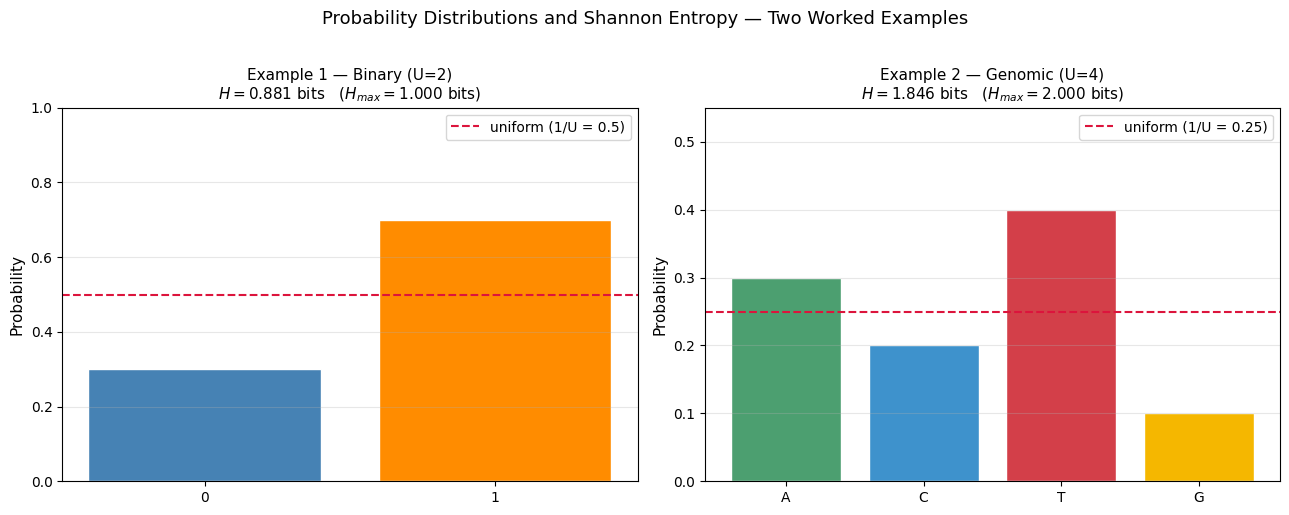

In [4]:
# Visualize the probability distributions and entropies for both examples
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: binary example ---
labels_bin = ['0', '1']
probs_bin = [3/10, 7/10]
colors_bin = ['steelblue', 'darkorange']
axes[0].bar(labels_bin, probs_bin, color=colors_bin, edgecolor='white')
axes[0].axhline(0.5, color='crimson', linestyle='--', linewidth=1.5,
                label='uniform (1/U = 0.5)')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Probability', fontsize=11)
axes[0].set_title(
    f'Example 1 — Binary (U=2)\n'
    f'$H = {H_bits:.3f}$ bits   ($H_{{max}} = {H_max_bits:.3f}$ bits)',
    fontsize=11,
)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# --- Right: genomic example ---
labels_dna = ['A', 'C', 'T', 'G']
probs_dna = [3/10, 2/10, 4/10, 1/10]
colors_dna = ['#4c9f70', '#3e92cc', '#d33f49', '#f5b700']
axes[1].bar(labels_dna, probs_dna, color=colors_dna, edgecolor='white')
axes[1].axhline(0.25, color='crimson', linestyle='--', linewidth=1.5,
                label='uniform (1/U = 0.25)')
axes[1].set_ylim(0, 0.55)
axes[1].set_ylabel('Probability', fontsize=11)
axes[1].set_title(
    f'Example 2 — Genomic (U=4)\n'
    f'$H = {H_dna:.3f}$ bits   ($H_{{max}} = {H_max_dna:.3f}$ bits)',
    fontsize=11,
)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Probability Distributions and Shannon Entropy — Two Worked Examples',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('probability_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 3: Why We Can't Quite Reach $H_{\max}$

In Example 2 ($N=10$, $U=4$) we got $H \approx 1.846$ bits, falling short of $H_{\max} = 2$ bits. **Why?**

$H_{\max}$ requires a perfectly uniform distribution, i.e. each nucleotide must appear exactly $N/U$ times. For $U=4$:

- $N = 4$: possible (1 of each)
- $N = 8$: possible (2 of each)
- $N = 12, 16, 20, \ldots$: possible (any multiple of $U$)
- $N = 10$: **impossible** — $10/4 = 2.5$, so at least one nucleotide must be over- or under-represented.

More generally, perfect uniformity is only achievable when $N$ is a multiple of $U$. For other values of $N$ there is always some unavoidable imbalance.

### As $N$ grows, the gap shrinks

For real genomes containing **millions or billions** of nucleotides, the rounding effect becomes negligible. The empirical distribution approaches whatever the true underlying distribution is, and the achievable entropy approaches that distribution's entropy. We can illustrate this with a small simulation.

### Presenter's Notes — Reaching the Maximum Entropy
![Why H_max is unreachable for N=10](Screenshots/Part_2_00_18_48.jpg)

*Screenshot at timestamp 00:18:48*

---

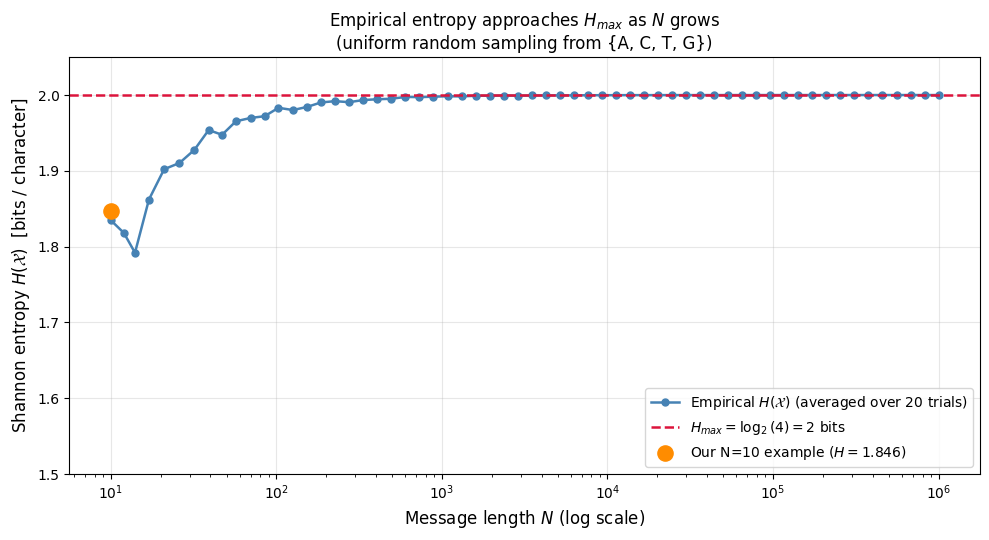

At N = 10:        H ≈ 1.8349 bits  (gap to H_max: 0.1651)
At N = 1000000:   H ≈ 2.0000 bits  (gap to H_max: 0.0000)


In [5]:
# Simulation: sample uniformly from {A, C, T, G} for increasing N and measure H(X).
# As N grows, the empirical entropy approaches H_max = 2 bits.
rng = np.random.default_rng(seed=42)
alphabet = ['A', 'C', 'T', 'G']
H_max = np.log2(len(alphabet))

N_values = np.unique(np.logspace(1, 6, 60).astype(int))  # 10 to 1,000,000
H_empirical = []
trials = 20  # average over multiple random draws to smooth the curve

for N in N_values:
    H_samples = []
    for _ in range(trials):
        seq = rng.choice(alphabet, size=N)
        H, _ = entropy_of_message(seq)
        H_samples.append(H)
    H_empirical.append(np.mean(H_samples))

H_empirical = np.array(H_empirical)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.semilogx(N_values, H_empirical, 'o-', color='steelblue', linewidth=1.8,
            markersize=5, label='Empirical $H(\\mathcal{X})$ (averaged over 20 trials)')
ax.axhline(H_max, color='crimson', linestyle='--', linewidth=1.8,
           label=f'$H_{{max}} = \\log_2(4) = {H_max:.0f}$ bits')

# Mark our N=10 example
ax.scatter([10], [H_dna], color='darkorange', s=120, zorder=5,
           label=f'Our N=10 example ($H = {H_dna:.3f}$)')

ax.set_xlabel('Message length $N$ (log scale)', fontsize=12)
ax.set_ylabel('Shannon entropy $H(\\mathcal{X})$  [bits / character]', fontsize=12)
ax.set_title('Empirical entropy approaches $H_{max}$ as $N$ grows\n'
             '(uniform random sampling from {A, C, T, G})', fontsize=12)
ax.set_ylim(1.5, 2.05)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('entropy_vs_N.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"At N = 10:        H ≈ {H_empirical[0]:.4f} bits  (gap to H_max: {H_max - H_empirical[0]:.4f})")
print(f"At N = {N_values[-1]:>7}:   H ≈ {H_empirical[-1]:.4f} bits  (gap to H_max: {H_max - H_empirical[-1]:.4f})")

---
## Section 4: Direct Comparison — Computing on Bits vs. Computing on Nucleotides

Earlier we noted that one *could* convert a nucleotide sequence into a binary string (A→`00`, C→`01`, T→`10`, G→`11`) and run the entropy analysis on the resulting bit string. We claimed this is unnecessary. Let's verify the entropies match — confirming the choice of representation is mathematically equivalent.

In [6]:
# Convert the genomic sequence to its 2-bit-per-symbol binary form
encoding = {'A': '00', 'C': '01', 'T': '10', 'G': '11'}
bit_string = ''.join(encoding[ch] for ch in message_dna)

print(f"Original (DNA):  {' '.join(message_dna)}")
print(f"Encoded (bits):  {' '.join(encoding[ch] for ch in message_dna)}")
print(f"Flat bit string: {bit_string}")
print()

# Entropy computed on the 4-letter alphabet (per nucleotide)
H_per_nucleotide, _ = entropy_of_message(message_dna)

# Entropy computed on the 2-letter alphabet (per bit), then scaled by 2 bits/nucleotide
H_per_bit, _ = entropy_of_message(list(bit_string))
H_per_nucleotide_via_bits = 2 * H_per_bit

print(f"H per nucleotide  (computed directly):     {H_per_nucleotide:.4f} bits / nucleotide")
print(f"H per bit         (computed on bit string): {H_per_bit:.4f} bits / bit")
print(f"H per nucleotide  (= 2 × H per bit):       {H_per_nucleotide_via_bits:.4f} bits / nucleotide")
print()
print("Note: these are NOT generally equal. Computing entropy on the flat bit")
print("string treats individual bits as independent, which loses the structure")
print("of the 2-bit codes. To recover the per-nucleotide entropy, compute it on")
print("the 2-bit *pairs* (which is identical to working on the original alphabet).")

Original (DNA):  C A A T T T T G A C
Encoded (bits):  01 00 00 10 10 10 10 11 00 01
Flat bit string: 01000010101010110001

H per nucleotide  (computed directly):     1.8464 bits / nucleotide
H per bit         (computed on bit string): 0.9710 bits / bit
H per nucleotide  (= 2 × H per bit):       1.9419 bits / nucleotide

Note: these are NOT generally equal. Computing entropy on the flat bit
string treats individual bits as independent, which loses the structure
of the 2-bit codes. To recover the per-nucleotide entropy, compute it on
the 2-bit *pairs* (which is identical to working on the original alphabet).


In [7]:
# Compute entropy on the 2-bit pair alphabet — this MUST equal the per-nucleotide entropy
pairs = [bit_string[i:i+2] for i in range(0, len(bit_string), 2)]
H_pairs, _ = entropy_of_message(pairs)

print(f"Pairs:           {pairs}")
print(f"H over 2-bit pairs:           {H_pairs:.4f} bits / pair")
print(f"H over nucleotides (direct):  {H_per_nucleotide:.4f} bits / nucleotide")
print(f"Match: {np.isclose(H_pairs, H_per_nucleotide)}")

Pairs:           ['01', '00', '00', '10', '10', '10', '10', '11', '00', '01']
H over 2-bit pairs:           1.8464 bits / pair
H over nucleotides (direct):  1.8464 bits / nucleotide
Match: True


---
## Summary

### Worked example results

| Example | Alphabet | $U$ | $N$ | Distribution | $H(\mathcal{X})$ | $H_{\max}$ | $I_{\text{total}}$ |
|---|---|---|---|---|---|---|---|
| **1. Binary** | $\{0, 1\}$ | 2 | 10 | 3 zeros, 7 ones | **0.881 bits** | 1 bit | 8.81 bits |
| **2. Genomic** | $\{A, C, T, G\}$ | 4 | 10 | 3 A, 2 C, 4 T, 1 G | **1.846 bits** | 2 bits | 18.46 bits |

### Key takeaways

1. **Computing $H(\mathcal{X})$ is just bookkeeping.** Count each symbol, divide by $N$ to get probabilities, and plug into the entropy sum.
2. **Imbalance reduces entropy.** In both examples, the empirical distribution was non-uniform, so $H < H_{\max}$.
3. **The choice of alphabet is a convenience, not a constraint.** A genomic sequence can be analyzed directly on $\{A,C,T,G\}$ or via a 2-bit binary encoding — they give the same per-nucleotide entropy (provided you keep the 2-bit pairs together).
4. **Finite-$N$ effects matter.** Perfect uniformity (and hence $H = H_{\max}$) is only reachable when $N$ is a multiple of $U$. For real genomes with millions of nucleotides, this rounding is negligible.

### What's next?

These calculations are the foundation for the **second law of information dynamics** and the broader framework of **information physics** built on top of Shannon's framework. The next lectures will explore how $H(\mathcal{X})$ behaves as a system **evolves over time** — suggesting there is a governing dynamics of information entropy analogous to thermodynamic entropy.

---

---

> 🧭 **Navigation** · [← Part 1: Introduction to Shannon's Information Theory](../Video_01/Shannon_Entropy.ipynb) · **Part 2 (current)** · *Part 3: coming soon*